In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
from google.colab import files

print("📂 Please select  'HR_comma_sep.csv'  from your PC...")
uploaded = files.upload()   # ← file picker popup appears here

# Automatically pick the uploaded filename
import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\n✅ File '{filename}' loaded successfully!")
print(f"   Shape : {df.shape}")
df.head()

📂 Please select  'HR_comma_sep.csv'  from your PC...


Saving HR_comma_sep.csv to HR_comma_sep.csv

✅ File 'HR_comma_sep.csv' loaded successfully!
   Shape : (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
print("=" * 55)
print("  DATASET INFO")
print("=" * 55)
df.info()

print("\n" + "=" * 55)
print("  MISSING VALUES")
print("=" * 55)
print(df.isnull().sum())

print("\n" + "=" * 55)
print("  STATISTICAL SUMMARY")
print("=" * 55)
print(df.describe())

print("\n" + "=" * 55)
print("  TARGET DISTRIBUTION  (left : 0=Stayed, 1=Left)")
print("=" * 55)
print(df['left'].value_counts())
print(f"\n  Retention Rate : {(df['left']==0).mean()*100:.1f}%")
print(f"  Attrition Rate : {(df['left']==1).mean()*100:.1f}%")

  DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB

  MISSING VALUES
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left      

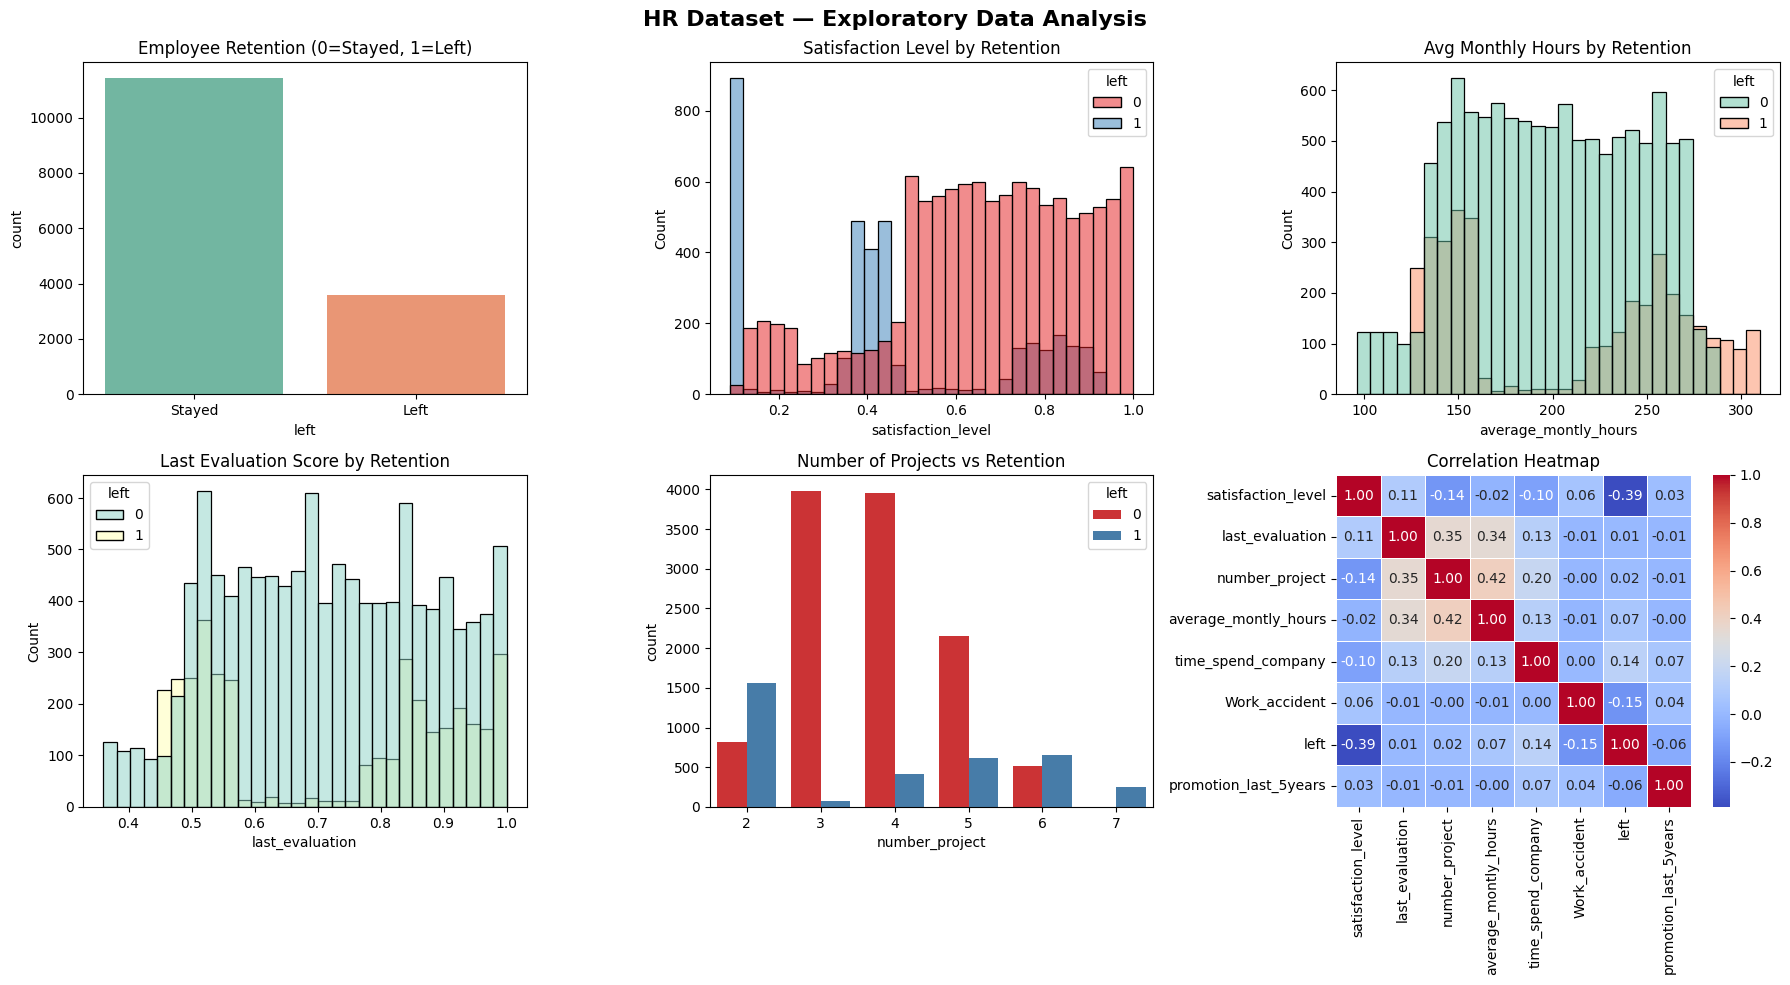

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("HR Dataset — Exploratory Data Analysis", fontsize=16, fontweight='bold')

# 1. Target distribution
sns.countplot(x='left', data=df, palette='Set2', ax=axes[0,0])
axes[0,0].set_title("Employee Retention (0=Stayed, 1=Left)")
axes[0,0].set_xticklabels(['Stayed', 'Left'])

# 2. Satisfaction level
sns.histplot(data=df, x='satisfaction_level', hue='left',
             bins=30, palette='Set1', ax=axes[0,1])
axes[0,1].set_title("Satisfaction Level by Retention")

# 3. Average monthly hours
sns.histplot(data=df, x='average_montly_hours', hue='left',
             bins=30, palette='Set2', ax=axes[0,2])
axes[0,2].set_title("Avg Monthly Hours by Retention")

# 4. Last evaluation
sns.histplot(data=df, x='last_evaluation', hue='left',
             bins=30, palette='Set3', ax=axes[1,0])
axes[1,0].set_title("Last Evaluation Score by Retention")

# 5. Number of projects
sns.countplot(x='number_project', hue='left', data=df,
              palette='Set1', ax=axes[1,1])
axes[1,1].set_title("Number of Projects vs Retention")

# 6. Correlation heatmap
num_df = df.select_dtypes(include=np.number)
sns.heatmap(num_df.corr(), annot=True, fmt=".2f",
            cmap='coolwarm', ax=axes[1,2], linewidths=0.5)
axes[1,2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

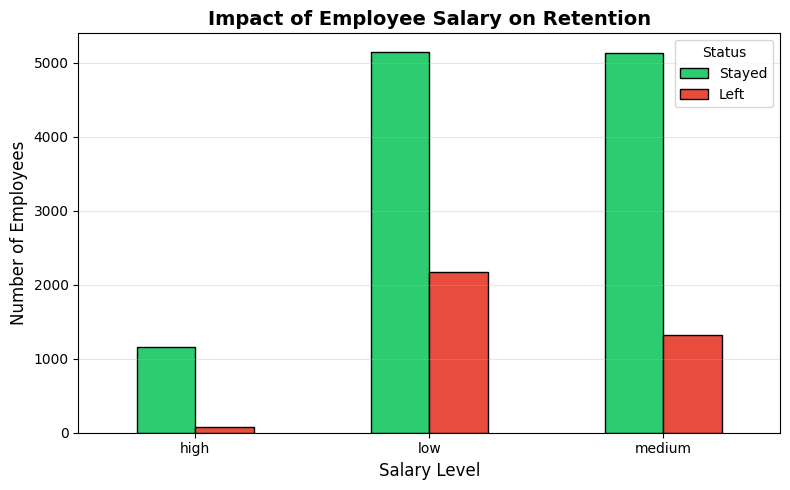


📊 Attrition Rate by Salary:
salary
high       6.63%
low       29.69%
medium    20.43%
Name: left, dtype: object


In [ ]:
plt.figure(figsize=(8, 5))
salary_retention = df.groupby(['salary', 'left']).size().unstack()
salary_retention.columns = ['Stayed', 'Left']
salary_retention.plot(kind='bar', color=['#2ecc71', '#e74c3c'],
                      edgecolor='black', figsize=(8, 5))
plt.title("Impact of Employee Salary on Retention", fontsize=14, fontweight='bold')
plt.xlabel("Salary Level", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Attrition rate by salary
print("\n📊 Attrition Rate by Salary:")
print(df.groupby('salary')['left'].mean().mul(100).round(2).astype(str) + "%")

<Figure size 1200x500 with 0 Axes>

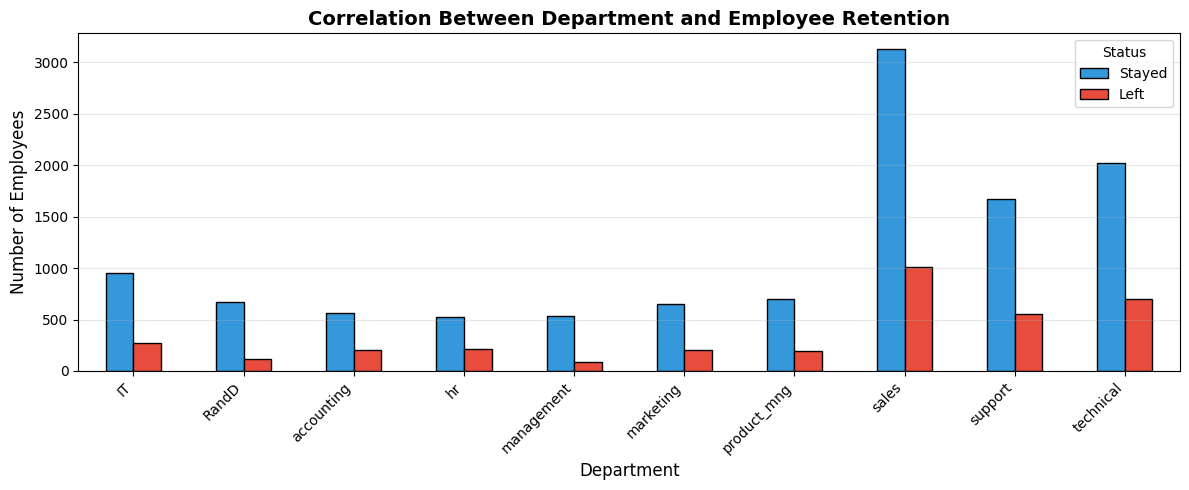


📊 Attrition Rate by Department:
Department
hr             29.09%
accounting      26.6%
technical      25.62%
support         24.9%
sales          24.49%
marketing      23.66%
IT             22.25%
product_mng    21.95%
RandD          15.37%
management     14.44%
Name: left, dtype: object


In [ ]:
plt.figure(figsize=(12, 5))
dept_retention = df.groupby(['Department', 'left']).size().unstack()
dept_retention.columns = ['Stayed', 'Left']
dept_retention.plot(kind='bar', color=['#3498db', '#e74c3c'],
                    edgecolor='black', figsize=(12, 5))
plt.title("Correlation Between Department and Employee Retention",
          fontsize=14, fontweight='bold')
plt.xlabel("Department", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Status")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Attrition rate by department
print("\n📊 Attrition Rate by Department:")
dept_rate = df.groupby('Department')['left'].mean().mul(100).round(2).sort_values(ascending=False)
print(dept_rate.astype(str) + "%")

In [ ]:
le = LabelEncoder()
df_model = df.copy()
df_model['salary']     = le.fit_transform(df_model['salary'])      # low=1, medium=2, high=0
df_model['Department'] = le.fit_transform(df_model['Department'])

# Features selected based on EDA impact
# satisfaction_level, last_evaluation, number_project,
# average_montly_hours, time_spend_company, salary have clear impact
features = ['satisfaction_level', 'last_evaluation', 'number_project',
            'average_montly_hours', 'time_spend_company',
            'Work_accident', 'promotion_last_5years', 'salary', 'Department']
target = 'left'

X = df_model[features]
y = df_model[target]

print("✅ Features selected:", features)
print(f"\n   X shape : {X.shape}")
print(f"   y shape : {y.shape}")

✅ Features selected: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years', 'salary', 'Department']

   X shape : (14999, 9)
   y shape : (14999,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 11999
Testing  samples : 3000


In [ ]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print("✅ Features scaled using StandardScaler")

✅ Features scaled using StandardScaler


In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("✅ Logistic Regression model trained!")

✅ Logistic Regression model trained!


In [ ]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print("=" * 50)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  ROC-AUC   : {auc:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["Stayed (0)", "Left (1)"]))

  Accuracy  : 0.7710  (77.10%)
  ROC-AUC   : 0.8115

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.80      0.93      0.86      2286
    Left (1)       0.54      0.26      0.35       714

    accuracy                           0.77      3000
   macro avg       0.67      0.60      0.61      3000
weighted avg       0.74      0.77      0.74      3000



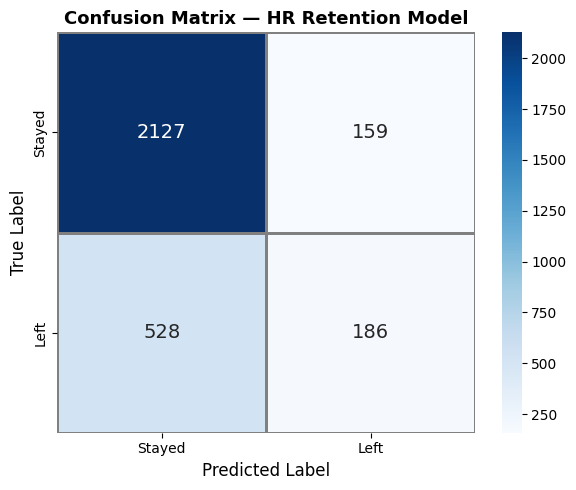


  True Positives  (correctly predicted Left)   : 186
  True Negatives  (correctly predicted Stayed) : 2127
  False Positives (wrongly predicted Left)     : 159
  False Negatives (wrongly predicted Stayed)   : 528


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Stayed", "Left"],
            yticklabels=["Stayed", "Left"],
            linewidths=1, linecolor='gray', annot_kws={"size": 14})
plt.title("Confusion Matrix — HR Retention Model",
          fontsize=13, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()

TP = cm[1,1]; TN = cm[0,0]; FP = cm[0,1]; FN = cm[1,0]
print(f"\n  True Positives  (correctly predicted Left)   : {TP}")
print(f"  True Negatives  (correctly predicted Stayed) : {TN}")
print(f"  False Positives (wrongly predicted Left)     : {FP}")
print(f"  False Negatives (wrongly predicted Stayed)   : {FN}")

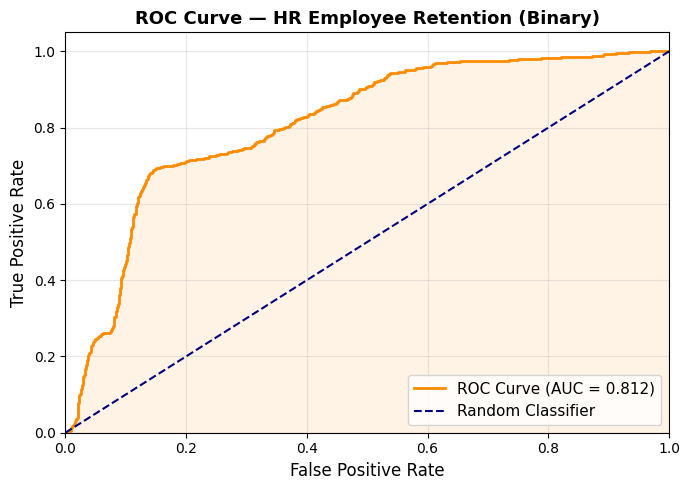

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], color='navy', lw=1.5, linestyle='--',
         label="Random Classifier")
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — HR Employee Retention (Binary)",
          fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

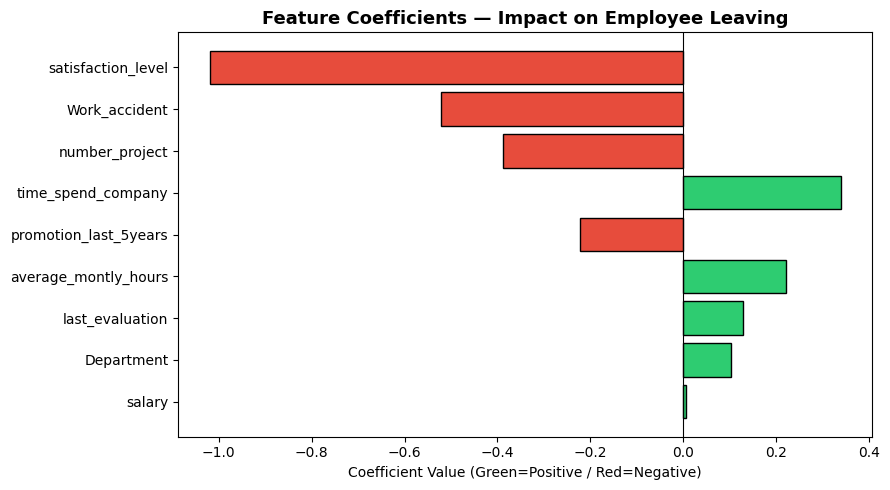


✅ Lab-3 Task 1 Complete — Binary Logistic Regression on HR Dataset!


In [ ]:
coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=True)

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]

plt.figure(figsize=(9, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'],
         color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Coefficients — Impact on Employee Leaving",
          fontsize=13, fontweight='bold')
plt.xlabel("Coefficient Value (Green=Positive / Red=Negative)")
plt.tight_layout()
plt.show()

print("\n✅ Lab-3 Task 1 Complete — Binary Logistic Regression on HR Dataset!")